In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
from ROOT import TH1F, TF1, TCanvas, gROOT, TLine, TLegend
from ROOT import kRed, kGreen, kBlue, kDashed

from scipy import odr

In [2]:
# ds_to_fiber = {'17h08': 'fiber 2', '16h59': 'fiber 1', '17h17':'fiber 3'} ##meas1
# ds_to_fiber = {'15h54': 'fiber 2', '14h43': 'fiber 1', '13h17':'fiber 3'} ##meas6
ds_to_fiber = {'12h40': 'fiber 2', '12h29': 'fiber 1', '12h47':'fiber 3'} ##meas5

def fit_baseline(data,draw=False):
    x = data["baseline"].to_numpy()
    y = data["filtered_amplitude"].to_numpy()
    
    m, c = np.polyfit(x, y, 1)

    if(draw):
        x_fit = np.linspace(np.min(x),np.max(x), 1000)
        y_fit = m*x_fit + c
        
        plt.scatter(x, y)
        plt.plot(x_fit,y_fit,color="orange")
        plt.text(np.average(x_fit), np.average(y_fit), f"y = {m:.3f}*x + {c:.3f}")
        plt.ylabel("Baseline")
        plt.xlabel("Filtered Amplitude")
        plt.show()
        
    return m,c 

def get_avg_amplitude(data,draw=False,tag=''):
    ampl = data["filtered_amplitude"].to_numpy()
    
    hist_name = f"ampl_{tag}" if tag else "ampl"
    canvas_name = f"c_{tag}" if tag else "c"
    
    h = TH1F(hist_name,hist_name,100,ampl.min()-5,ampl.max()+5)
    
    for value in ampl:
        h.Fill(value)
    
    h.Fit("gaus","QS")

    gaus = h.GetFunction("gaus")
    mean  = gaus.GetParameter(1)
    sigma = gaus.GetParameter(2)

    
    if(draw):
        gROOT.SetBatch(False)
        c = TCanvas(canvas_name,canvas_name,800,600)
        h.Draw("HIST")
        c.Update()
        return mean, sigma, c, h

    return mean,sigma

def get_baseline_corrected_amplitude(data,draw=False,tag=''):
    m,c = fit_baseline(data,draw)
    
    avg_ampl,_ = get_avg_amplitude(data)
    # avg_ampl = data["fitted_amplitude"].mean()
    
    return  data["filtered_amplitude"] * avg_ampl / (data["baseline"]*m + c)


def ntd1_vs_ntd2_amplitude(datasets,center_ds):
    for ds in datasets:
        data = datasets[ds]
        # print(ds)
        ampl_ntd1 = get_baseline_corrected_amplitude(data["NTD1"])
        ampl_ntd2 = get_baseline_corrected_amplitude(data["NTD2"])
    
        plt.scatter(ampl_ntd1,ampl_ntd2,label=ds_to_fiber[ds],s=.1)

    x = np.linspace(0,10000)
    
    data = datasets[center_ds]
    avg_ntd1 = np.average(get_baseline_corrected_amplitude(data["NTD1"]))
    avg_ntd2 = np.average(get_baseline_corrected_amplitude(data["NTD2"]))
    
    m = avg_ntd2/avg_ntd1
    plt.plot(x,m*x,"--",color="grey",lw=1)
    plt.legend()
    

In [3]:
column_names = ["trigger_position", "raw_amplitude", "filtered_amplitude", 
               "baseline", "baseline_RMS", "correlation", "TV", 
               "tvl", "tvr", "fitted_amplitude", "fitted_baseline", "rise_time", 
               "decay_time", "delayed_amplitude", "mean_time", "area_raw_pulse",
               "area_filtered_pulse", "baseline_ampl", "t10_cf"
              ]
ntps = {}
datasets = {}
ds_keys = []
base_dir = "/Users/ebrandani/Downloads/for_enzo"
meas_dir = "meas5"
ntp_directory = os.path.join(base_dir,meas_dir)

for file in os.listdir(ntp_directory): 
    if("ntp" in file and not ("info" in file)):
        ntp_name = file.split("_")[1].rstrip(".ntp")
        ds = ntp_name.rstrip(".BINNTD12")
        ntps[file.split("_")[1].rstrip(".ntp")]  = pd.read_csv(os.path.join(ntp_directory,file),sep=r"\s+",names=column_names)
        if(not ds in ds_keys): ds_keys.append(ds)
for ds in ds_keys:
    datasets[ds] = pd.concat([ntps[ds + ".BINNTD1"],ntps[ds + ".BINNTD2"]], axis=1, join="inner", keys=["NTD1","NTD2"])

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/Users/ebrandani/Downloads/for_enzo\\meas5'

In [ ]:
datasets.keys()

dict_keys(['12h29', '12h40', '12h47'])

(2000.0, 6500.0)

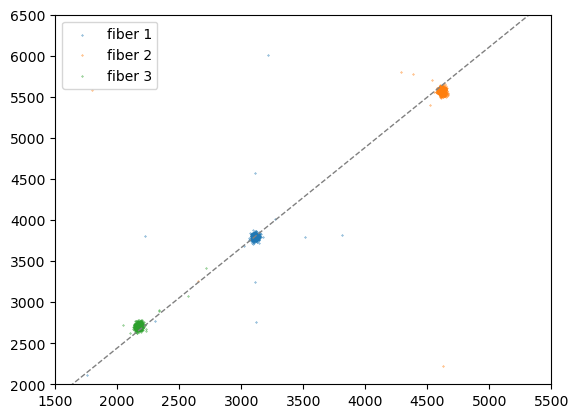

In [ ]:
ntd1_vs_ntd2_amplitude(datasets,'12h29')
plt.xlim(1500,5500)
plt.ylim(2000,6500)

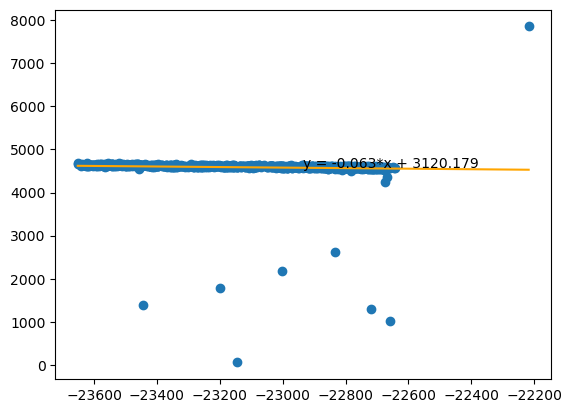

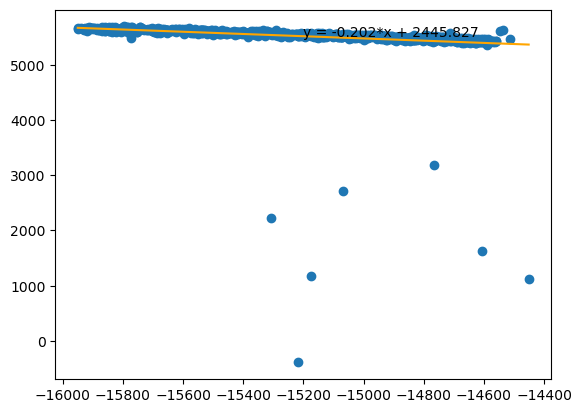

In [ ]:
test1 = get_baseline_corrected_amplitude(datasets['12h40']['NTD1'],True)
test2 = get_baseline_corrected_amplitude(datasets['12h40']['NTD2'],True)

In [ ]:
c = TCanvas()
gROOT.SetBatch(False)
# color = {'17h08': kRed, '16h59': kBlue, '17h17':kGreen} ##meas1
color = {'12h29':kBlue, '12h40':kRed, '12h47':kGreen} ##meas5

hists = []
fits = []
lines = []
ymax = 0
first_hist = TH1F()
legend = TLegend()
for i,ds in enumerate(datasets):
    t1 = datasets[ds]['NTD1']["t10_cf"]
    t2 = datasets[ds]['NTD2']["t10_cf"]
    delta_t = t1-t2
    # ampl = datasets[ds]['NTD1']["rise_time"]
    x_binOffset = 1e-4
    x_min = 3.2e-3#delta_t.min() - x_binOffset
    x_max = 4.6e-3#delta_t.max() + x_binOffset
    
    h = TH1F(ds,ds,100,x_min,x_max)
    
    
    
    for value in delta_t:
        h.Fill(value)
    h.Scale( 1/h.Integral())
        
    fit = TF1(f"gaus_{ds}", "gaus", x_min, x_max)
    fit.SetLineColor(color[ds])
    fits.append(fit)
    
    h.Fit(fit,"0")
    h.SetStats(False)
    h.SetLineColor(color[ds])
    
    hists.append(h)

    if(i == 0): 
        first_hist = h
        h.Draw("HIST")
    else: h.Draw("HIST SAME")

    fit.Draw("L SAME")

    peak_x = fit.GetParameter(1)                 # mean of Gaussian
    peak_y = fit.Eval(peak_x)                    # height at the mean (== fit.GetParameter(0))
    if peak_y > ymax : 
        ymax = peak_y
        first_hist.SetMaximum(ymax +.02)
    vline = TLine(peak_x, 0.0, peak_x, peak_y)
    vline.SetLineColor(color[ds])
    vline.SetLineStyle(kDashed)
    vline.SetLineWidth(2)
    vline.Draw("SAME")
    lines.append(vline)   # keep reference
    legend.AddEntry(fit,f"{ds_to_fiber[ds]}: {peak_x*1000:.5f} ms","l")

legend.Draw()
first_hist.SetTitle(";#Deltat(NTD1-NTD2);Events [a.u.]")
    

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      66.4796
NDf                       =           41
Edm                       =  9.35532e-06
NCalls                    =           63
Constant                  =    0.0609823   +/-   0.00254466  
Mean                      =   0.00395007   +/-   3.11389e-06 
Sigma                     =  8.59296e-05   +/-   2.29614e-06  	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      47.2704
NDf                       =           35
Edm                       =  8.95115e-10
NCalls                    =           71
Constant                  =    0.0696237   +/-   0.00284666  
Mean                      =    0.0039332   +/-   2.75578e-06 
Sigma                     =  7.68098e-05   +/-   1.98557e-06  	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      50.3312
NDf                   